# Current Signature Dataset - Deep Learning (CNN & LSTM)

This notebook implements **Deep Learning models (1D CNN and LSTM)** for fault diagnosis using raw time-series data from the **Mendeley Current Signature Dataset**.

## Objectives
1.  **Advanced Visualization**: Analyze Raw Signals, FFT Spectra, and Spectrograms.
2.  **Deep Learning Models**: Train 1D CNN (Spatial) and LSTM (Temporal) models.
3.  **Evaluation**: Compare performance using ROC Curves, Confusion Matrices, and t-SNE.

## 1. Setup & Imports

In [1]:
# REPLACED BY DEBUG SCRIPT


Imports and CurrentSignatureLoader loaded successfully!


## 2. Load Raw Data

In [2]:
DATA_DIR = r'../Current Signature Data/Current Signature Dataset of Three-Phase Induction Motor under Varying Load Conditions'

loader = CurrentSignatureLoader(DATA_DIR)
print("Loading Raw Data... This may take a moment.")

# Load raw windows (Samples, 1000, 3)
X, y = loader.load_raw_data(window_size=1000, stride=1000)

print(f"\nData Loaded:")
print(f"X Shape: {X.shape}")
print(f"y Shape: {y.shape}")

Loading Raw Data... This may take a moment.
Found 8 folders for Raw Data Loading...
Processing folder: 3-Phase-current-0.7mm-bearing-fault -> Label: bearing_fault
  Found 6 CSV files
  Loaded 143 windows from 0.7inner-100watt.csv
  Loaded 125 windows from 0.7inner-200watt.csv
  Loaded 113 windows from 0.7inner-300watt.csv
  Loaded 130 windows from 0.7outer-100watt.csv
  Loaded 130 windows from 0.7outer-200watt.csv
  Loaded 66 windows from 0.7outer-300watt.csv
Processing folder: 3-Phase-current-0.9mm-bearing-fault -> Label: bearing_fault
  Found 6 CSV files
  Loaded 152 windows from 0.9inner-100watt.csv
  Loaded 137 windows from 0.9inner-200watt.csv
  Loaded 132 windows from 0.9inner-300watt.csv
  Loaded 140 windows from 0.9outer-100watt.csv
  Loaded 140 windows from 0.9outer-200watt.csv
  Loaded 122 windows from 0.9outer-300watt.csv
Processing folder: 3-Phase-current-1.1mm-bearing-fault -> Label: bearing_fault
  Found 6 CSV files
  Loaded 136 windows from 1.1inner-100watt.csv
  Loaded 

## 3. Advanced Data Visualization

Plotting Raw Signals...


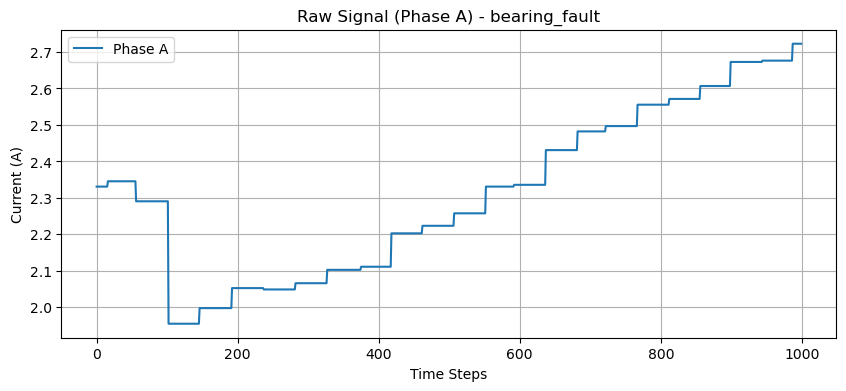

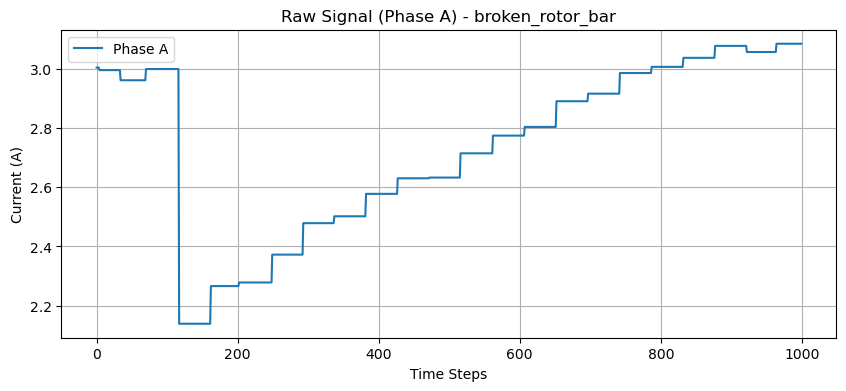

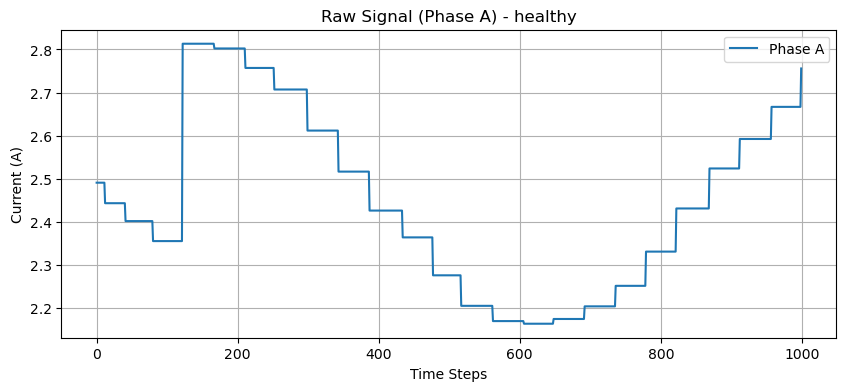

Plotting FFT Spectra...


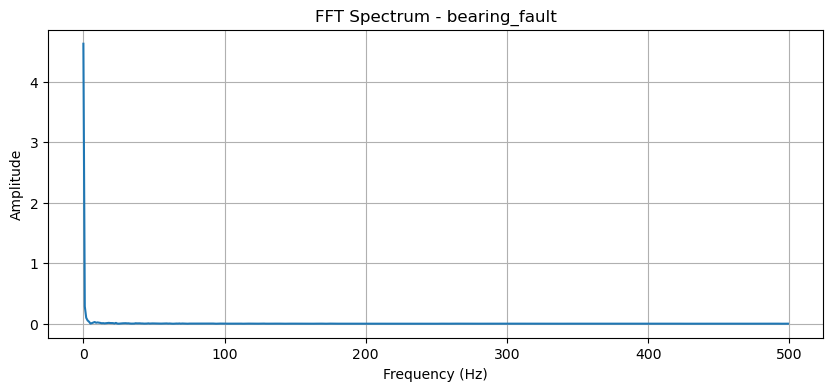

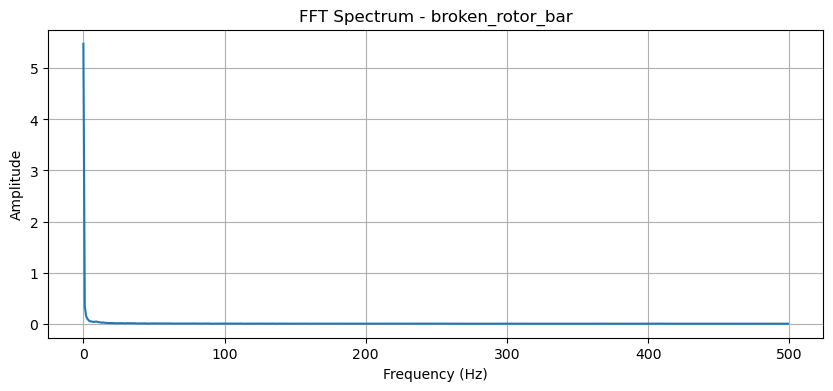

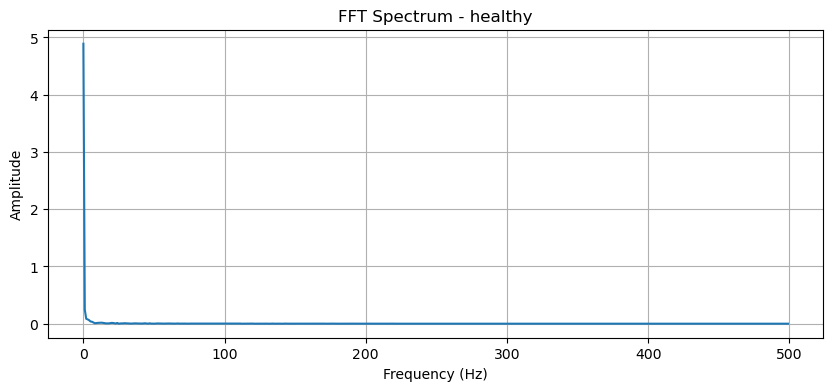

Plotting Spectrograms...


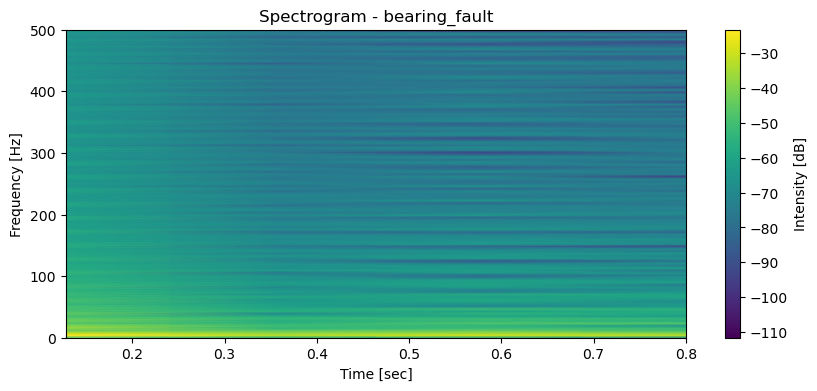

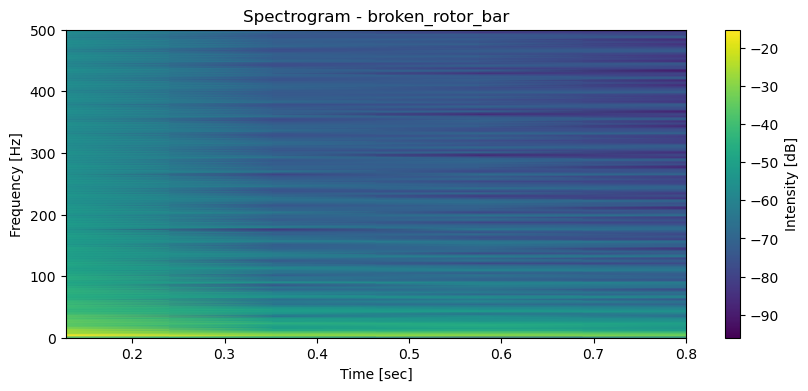

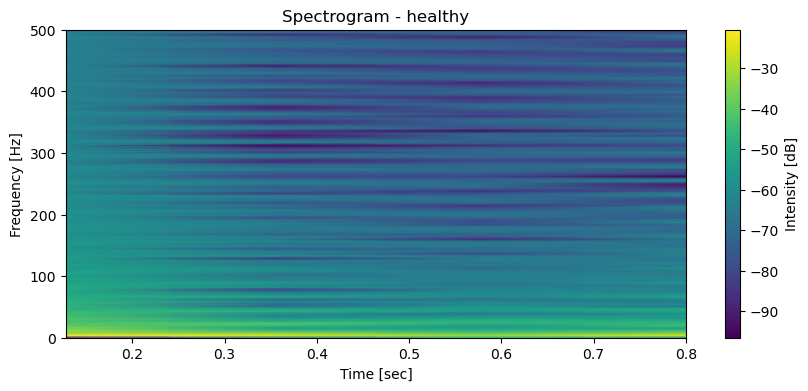

In [3]:
# Helper function to get one sample per class
unique_classes = np.unique(y)
samples = {}
for cls in unique_classes:
    idx = np.where(y == cls)[0][0]
    samples[cls] = X[idx]

# --- 1. Raw Signal Plots (Separate Figures) ---
print("Plotting Raw Signals...")
for cls, signal in samples.items():
    plt.figure(figsize=(10, 4))
    plt.plot(signal[:, 0], label='Phase A') # Plotting just Phase A for clarity
    plt.title(f"Raw Signal (Phase A) - {cls}")
    plt.xlabel("Time Steps")
    plt.ylabel("Current (A)")
    plt.legend()
    plt.grid(True)
    plt.show()

# --- 2. FFT Spectrum Analysis (Separate Figures) ---
print("Plotting FFT Spectra...")
for cls, signal in samples.items():
    plt.figure(figsize=(10, 4))
    # Compute FFT
    N = len(signal)
    T = 1.0 / 1000.0 # Assuming 1kHz sampling for visualization scale
    yf = np.fft.fft(signal[:, 0])
    xf = np.fft.fftfreq(N, T)[:N//2]
    plt.plot(xf, 2.0/N * np.abs(yf[0:N//2]))
    plt.title(f"FFT Spectrum - {cls}")
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Amplitude")
    plt.grid(True)
    plt.show()

# --- 3. Spectrograms (Separate Figures) ---
print("Plotting Spectrograms...")
for cls, signal in samples.items():
    plt.figure(figsize=(10, 4))
    f, t, Sxx = spectrogram(signal[:, 0], fs=1000)
    plt.pcolormesh(t, f, 10 * np.log10(Sxx), shading='gouraud')
    plt.ylabel('Frequency [Hz]')
    plt.xlabel('Time [sec]')
    plt.title(f"Spectrogram - {cls}")
    plt.colorbar(label='Intensity [dB]')
    plt.show()

## 4. Preprocessing

In [4]:
# Encode Labels
le = LabelEncoder()
y_enc = le.fit_transform(y)
class_names = le.classes_
print(f"Classes: {class_names}")

# Split Data (Use y_enc for labels to support SMOTE)
X_train, X_test, y_train, y_test = train_test_split(X, y_enc, test_size=0.2, random_state=42, stratify=y_enc)

# --- Data Augmentation ---
def add_noise(data, noise_level=0.005):
    noise = np.random.normal(0, noise_level, data.shape)
    return data + noise

def time_shift(data, shift_max=50):
    shift = np.random.randint(-shift_max, shift_max)
    return np.roll(data, shift, axis=1)

print("Augmenting Training Data...")
X_train_noise = add_noise(X_train)
X_train_shift = np.array([time_shift(x) for x in X_train])

# Combine
X_train = np.concatenate((X_train, X_train_noise, X_train_shift), axis=0)
y_train = np.concatenate((y_train, y_train, y_train), axis=0)
print(f"Augmented Train Shape: {X_train.shape}")

# Handle NaNs (Fix for ValueError)
if np.isnan(X_train).any():
    print("NaNs found in training data. Imputing with 0...")
    X_train = np.nan_to_num(X_train, nan=0.0)

# Handle Class Imbalance using SMOTE
print("Applying SMOTE to balance the training data...")
from imblearn.over_sampling import SMOTE

# SMOTE works on 2D data (Samples, Features)
n_samples, n_time, n_channels = X_train.shape
X_train_flat = X_train.reshape(n_samples, -1)

# Apply SMOTE
smote = SMOTE(random_state=42)
X_train_resampled_flat, y_train_resampled = smote.fit_resample(X_train_flat, y_train)

# Reshape back to 3D
X_train = X_train_resampled_flat.reshape(-1, n_time, n_channels)
y_train_labels = y_train_resampled

print(f"Resampled Training Shape: {X_train.shape}, {y_train_labels.shape}")

# Convert to Categorical for Deep Learning
y_train = to_categorical(y_train_labels)
y_test = to_categorical(y_test)

# Scale Data (StandardScaler per channel)
# Reshape to (Samples*Time, Channels)
X_train_flat_scale = X_train.reshape(-1, n_channels)
X_test_flat_scale = X_test.reshape(-1, n_channels)

# Handle NaNs in Test Data if any
if np.isnan(X_test_flat_scale).any():
     X_test_flat_scale = np.nan_to_num(X_test_flat_scale, nan=0.0)

scaler = StandardScaler()
X_train_scaled_flat = scaler.fit_transform(X_train_flat_scale)
X_test_scaled_flat = scaler.transform(X_test_flat_scale)

# Reshape back to (Samples, Time, Channels)
X_train_scaled = X_train_scaled_flat.reshape(-1, n_time, n_channels)
X_test_scaled = X_test_scaled_flat.reshape(-1, n_time, n_channels)

print(f"Train Scaled Shape: {X_train_scaled.shape}")
print(f"Test Scaled Shape: {X_test_scaled.shape}")


Classes: ['bearing_fault' 'broken_rotor_bar' 'healthy']
Augmenting Training Data...
Augmented Train Shape: (12402, 1000, 3)
Applying SMOTE to balance the training data...
Resampled Training Shape: (34425, 1000, 3), (34425,)
Train Scaled Shape: (34425, 1000, 3)
Test Scaled Shape: (1034, 1000, 3)


## 5. Model 1: 1D CNN

In [5]:
def build_cnn(input_shape, num_classes):
    model = Sequential([
        Input(shape=input_shape), # Explicit Input layer for Keras 3 compatibility
        Conv1D(64, kernel_size=3, activation='relu'),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        
        Conv1D(128, kernel_size=3, activation='relu'),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        
        Conv1D(256, kernel_size=3, activation='relu'),
        BatchNormalization(),
        GlobalAveragePooling1D(),
        
        Dense(128, activation='relu'),
        Dropout(0.5),
        Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

cnn_model = build_cnn((1000, 3), len(class_names))
# Explicitly build to ensure inputs are defined
cnn_model.build(input_shape=(None, 1000, 3))
cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 998, 64)        │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 998, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 499, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 497, 128)       │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 497, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 248, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 246, 256)       │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 246, 256)       │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 158,979 (621.01 KB)

 Trainable params: 158,083 (617.51 KB)

 Non-trainable params: 896 (3.50 KB)

In [6]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-5)
]

print("Training CNN...")
history_cnn = cnn_model.fit(
    X_train_scaled, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=callbacks,
    verbose=1
)

Training CNN...
Epoch 1/50
861/861 ━━━━━━━━━━━━━━━━━━━━ 178s 201ms/step - accuracy: 0.7028 - loss: 0.5724 - val_accuracy: 1.0000 - val_loss: 4.1785e-07 - learning_rate: 0.0010
Epoch 2/50
861/861 ━━━━━━━━━━━━━━━━━━━━ 188s 218ms/step - accuracy: 0.7629 - loss: 0.4763 - val_accuracy: 1.0000 - val_loss: 6.9815e-04 - learning_rate: 0.0010
Epoch 3/50
861/861 ━━━━━━━━━━━━━━━━━━━━ 192s 223ms/step - accuracy: 0.7911 - loss: 0.4381 - val_accuracy: 1.0000 - val_loss: 2.2302e-06 - learning_rate: 0.0010
Epoch 4/50
861/861 ━━━━━━━━━━━━━━━━━━━━ 192s 223ms/step - accuracy: 0.8092 - loss: 0.4098 - val_accuracy: 1.0000 - val_loss: 1.4867e-06 - learning_rate: 0.0010
Epoch 5/50
861/861 ━━━━━━━━━━━━━━━━━━━━ 191s 222ms/step - accuracy: 0.8200 - loss: 0.3898 - val_accuracy: 1.0000 - val_loss: 2.3548e-09 - learning_rate: 0.0010
Epoch 6/50
861/861 ━━━━━━━━━━━━━━━━━━━━ 192s 223ms/step - accuracy: 0.8351 - loss: 0.3631 - val_accuracy: 1.0000 - val_loss: 2.2474e-08 - learning_rate: 0.0010
Epoch 7/50
861/861 ━━━━━

## 6. Model 2: LSTM

In [7]:
def build_lstm(input_shape, num_classes):
    model = Sequential([
        Input(shape=input_shape),
        LSTM(64, return_sequences=True),
        LSTM(64),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

lstm_model = build_lstm((1000, 3), len(class_names))
lstm_model.build(input_shape=(None, 1000, 3))
lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 1000, 64)       │        17,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 54,787 (214.01 KB)

 Trainable params: 54,787 (214.01 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
print("Training LSTM...")
history_lstm = lstm_model.fit(
    X_train_scaled, y_train,
    epochs=30, # LSTM is slower, fewer epochs for demo
    batch_size=64,
    validation_split=0.2,
    callbacks=callbacks,
    verbose=1
)

Training LSTM...
Epoch 1/30
431/431 ━━━━━━━━━━━━━━━━━━━━ 740s 2s/step - accuracy: 0.5525 - loss: 0.7174 - val_accuracy: 1.0000 - val_loss: 3.1450e-04 - learning_rate: 0.0010
Epoch 2/30
431/431 ━━━━━━━━━━━━━━━━━━━━ 706s 2s/step - accuracy: 0.6049 - loss: 0.5991 - val_accuracy: 1.0000 - val_loss: 0.0012 - learning_rate: 0.0010
Epoch 3/30
431/431 ━━━━━━━━━━━━━━━━━━━━ 727s 2s/step - accuracy: 0.6332 - loss: 0.5681 - val_accuracy: 1.0000 - val_loss: 1.9991e-04 - learning_rate: 0.0010
Epoch 4/30
431/431 ━━━━━━━━━━━━━━━━━━━━ 719s 2s/step - accuracy: 0.6365 - loss: 0.5699 - val_accuracy: 1.0000 - val_loss: 2.1813e-04 - learning_rate: 0.0010
Epoch 5/30
431/431 ━━━━━━━━━━━━━━━━━━━━ 755s 2s/step - accuracy: 0.6436 - loss: 0.5711 - val_accuracy: 1.0000 - val_loss: 4.9358e-04 - learning_rate: 0.0010
Epoch 6/30
431/431 ━━━━━━━━━━━━━━━━━━━━ 744s 2s/step - accuracy: 0.6632 - loss: 0.5400 - val_accuracy: 0.9994 - val_loss: 0.0026 - learning_rate: 5.0000e-04
Epoch 7/30
431/431 ━━━━━━━━━━━━━━━━━━━━ 720s 

## 7. Evaluation & Comparison

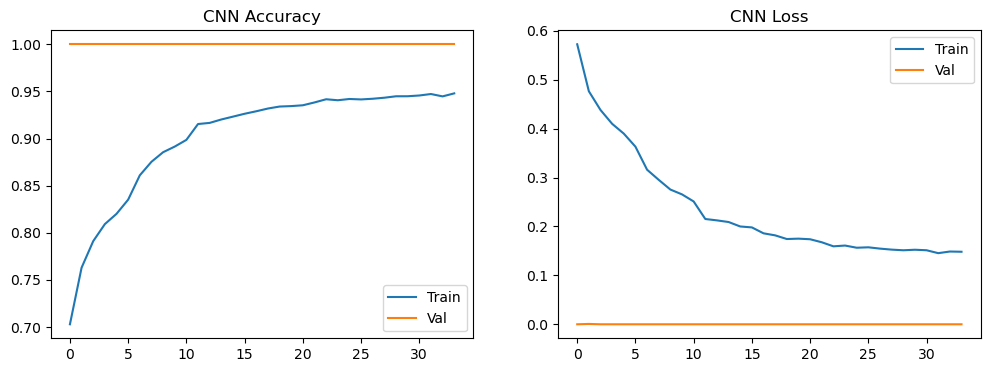

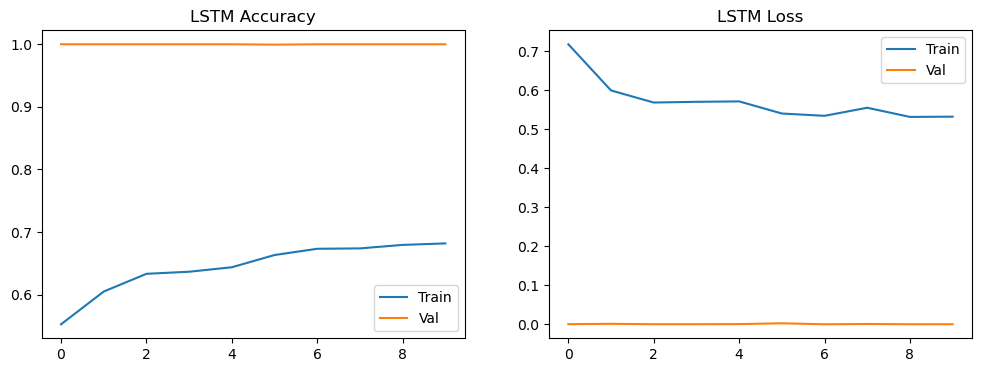

33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step
33/33 ━━━━━━━━━━━━━━━━━━━━ 11s 327ms/step


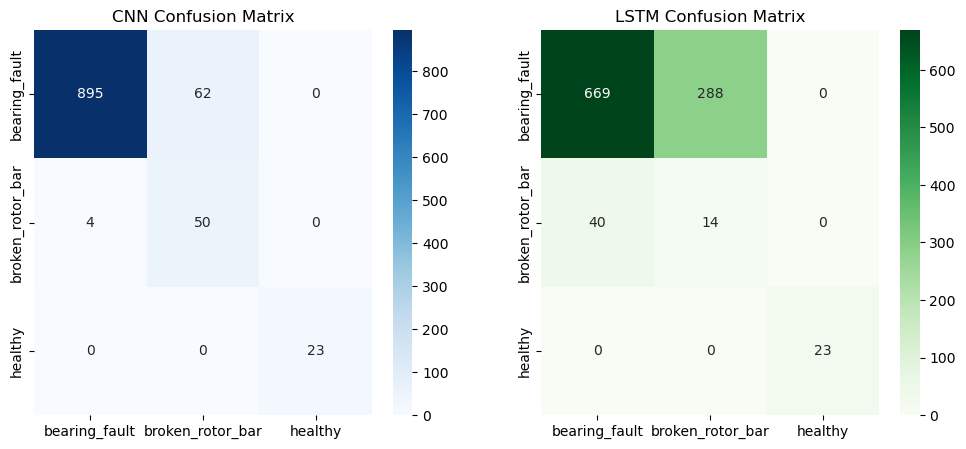

33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step


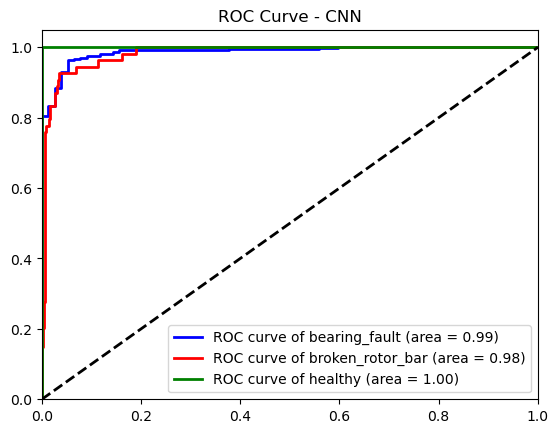

33/33 ━━━━━━━━━━━━━━━━━━━━ 10s 293ms/step


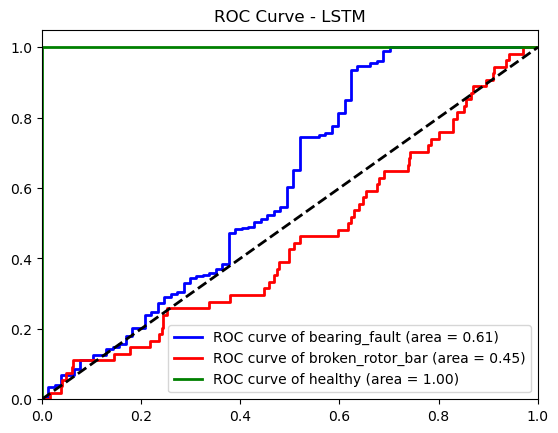

In [9]:
# Plot Training History
def plot_history(history, title):
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train')
    plt.plot(history.history['val_accuracy'], label='Val')
    plt.title(f'{title} Accuracy')
    plt.legend()
    
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train')
    plt.plot(history.history['val_loss'], label='Val')
    plt.title(f'{title} Loss')
    plt.legend()
    plt.show()

plot_history(history_cnn, "CNN")
plot_history(history_lstm, "LSTM")

# --- Confusion Matrices ---
y_pred_cnn = np.argmax(cnn_model.predict(X_test_scaled), axis=1)
y_pred_lstm = np.argmax(lstm_model.predict(X_test_scaled), axis=1)
y_true = np.argmax(y_test, axis=1)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(confusion_matrix(y_true, y_pred_cnn), annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names, ax=axes[0])
axes[0].set_title("CNN Confusion Matrix")

sns.heatmap(confusion_matrix(y_true, y_pred_lstm), annot=True, fmt='d', cmap='Greens', 
            xticklabels=class_names, yticklabels=class_names, ax=axes[1])
axes[1].set_title("LSTM Confusion Matrix")
plt.show()

# --- ROC Curves ---
def plot_roc(model, X_test, y_test, title):
    y_score = model.predict(X_test)
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    n_classes = y_test.shape[1]
    
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_test[:, i], y_score[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
        
    plt.figure()
    colors = ['blue', 'red', 'green']
    for i, color in zip(range(n_classes), colors):
        plt.plot(fpr[i], tpr[i], color=color, lw=2,
                 label='ROC curve of {0} (area = {1:0.2f})'.format(class_names[i], roc_auc[i]))
    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.title(f'ROC Curve - {title}')
    plt.legend(loc="lower right")
    plt.show()

plot_roc(cnn_model, X_test_scaled, y_test, "CNN")
plot_roc(lstm_model, X_test_scaled, y_test, "LSTM")

## 8. Feature Space Visualization (t-SNE)

--- Evaluating CNN Model ---
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step
Classification Report:
                  precision    recall  f1-score   support

   bearing_fault       1.00      0.94      0.96       957
broken_rotor_bar       0.45      0.93      0.60        54
         healthy       1.00      1.00      1.00        23

        accuracy                           0.94      1034
       macro avg       0.81      0.95      0.86      1034
    weighted avg       0.97      0.94      0.95      1034



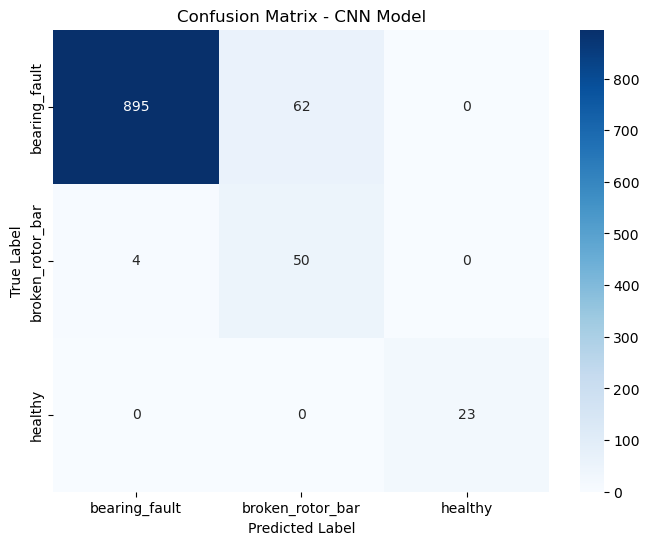

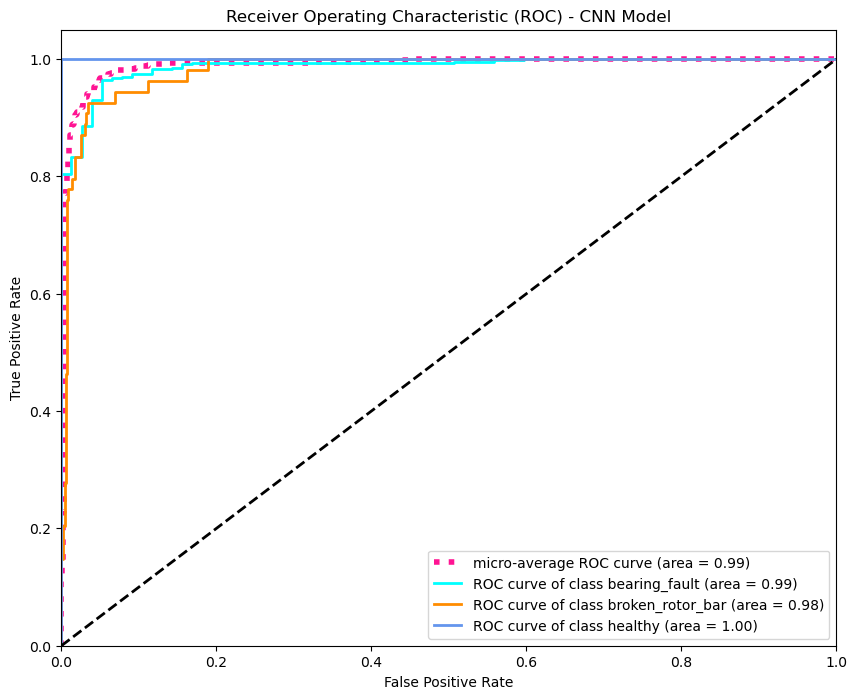

Macro Average ROC AUC: 0.9900
--- Evaluating LSTM Model ---
33/33 ━━━━━━━━━━━━━━━━━━━━ 10s 291ms/step
Classification Report:
                  precision    recall  f1-score   support

   bearing_fault       0.94      0.70      0.80       957
broken_rotor_bar       0.05      0.26      0.08        54
         healthy       1.00      1.00      1.00        23

        accuracy                           0.68      1034
       macro avg       0.66      0.65      0.63      1034
    weighted avg       0.90      0.68      0.77      1034



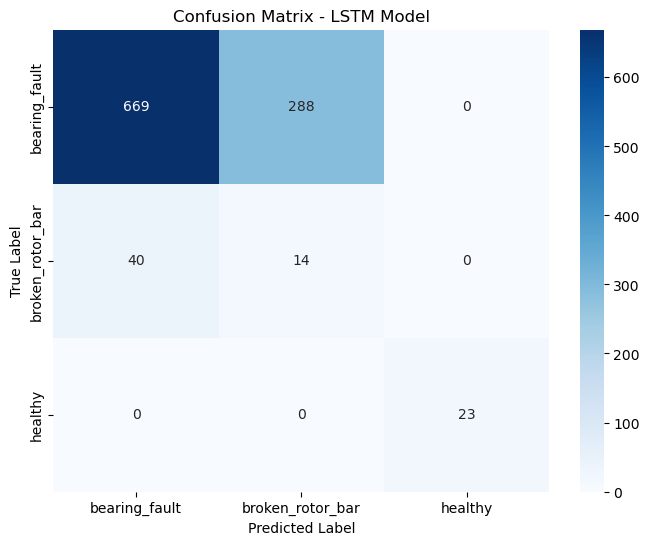

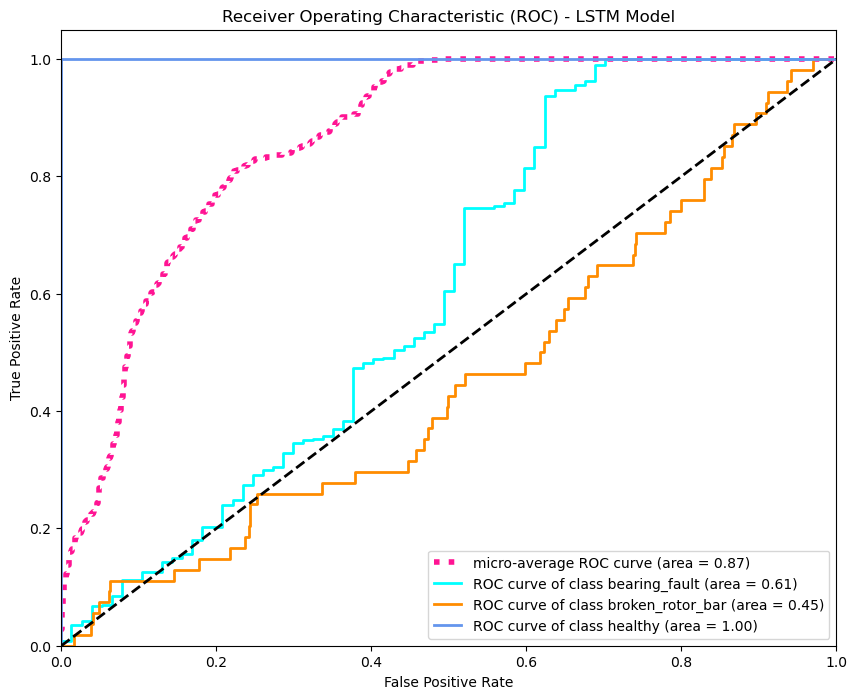

Macro Average ROC AUC: 0.6859


In [10]:
# Evaluation & Comparison
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def evaluate_model(model, X_test, y_test, model_name):
    print(f"--- Evaluating {model_name} ---")
    
    # Predictions
    y_pred_prob = model.predict(X_test)
    y_pred = np.argmax(y_pred_prob, axis=1)
    y_true = np.argmax(y_test, axis=1)
    
    # Classification Report
    print("Classification Report:")
    print(classification_report(y_true, y_pred, target_names=class_names))
    
    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Confusion Matrix - {model_name}')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()
    
    # ROC Curve (Multi-class)
    n_classes = y_test.shape[1]
    
    # Compute ROC curve and ROC area for each class
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_test[:, i], y_pred_prob[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
        
    # Compute micro-average ROC curve and ROC area
    fpr["micro"], tpr["micro"], _ = roc_curve(y_test.ravel(), y_pred_prob.ravel())
    roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])
    
    # Plot ROC curves
    plt.figure(figsize=(10, 8))
    plt.plot(fpr["micro"], tpr["micro"],
             label='micro-average ROC curve (area = {0:0.2f})'
                   ''.format(roc_auc["micro"]),
             color='deeppink', linestyle=':', linewidth=4)
             
    colors = ['aqua', 'darkorange', 'cornflowerblue']
    # Ensure we have enough colors if more classes
    if len(colors) < n_classes:
        colors = sns.color_palette("husl", n_classes)
        
    for i, color in zip(range(n_classes), colors):
        plt.plot(fpr[i], tpr[i], color=color, lw=2,
                 label='ROC curve of class {0} (area = {1:0.2f})'
                 ''.format(class_names[i], roc_auc[i]))
                 
    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'Receiver Operating Characteristic (ROC) - {model_name}')
    plt.legend(loc="lower right")
    plt.show()
    
    # Calculate Macro Average AUC
    try:
        macro_roc_auc = roc_auc_score(y_test, y_pred_prob, multi_class='ovr', average='macro')
        print(f"Macro Average ROC AUC: {macro_roc_auc:.4f}")
    except Exception as e:
        print(f"Could not calculate Macro AUC: {e}")

# Evaluate CNN
if 'cnn_model' in locals():
    evaluate_model(cnn_model, X_test_scaled, y_test, "CNN Model")

# Evaluate LSTM
if 'lstm_model' in locals():
    evaluate_model(lstm_model, X_test_scaled, y_test, "LSTM Model")


In [11]:
# Save Models
save_dir = r'../Trained_models/current_signature_dl'
os.makedirs(save_dir, exist_ok=True)

cnn_model.save(os.path.join(save_dir, 'cnn_model.keras'))
lstm_model.save(os.path.join(save_dir, 'lstm_model.keras'))
joblib.dump(scaler, os.path.join(save_dir, 'scaler.pkl'))
joblib.dump(le, os.path.join(save_dir, 'label_encoder.pkl'))

print(f"Models saved to {save_dir}")

Models saved to ../Trained_models/current_signature_dl
